# Gaia orbit: faint companion or hidden twin?
**Question:** a Gaia astrometric orbit says "brown dwarf". Could it be a near-equal-mass star?

Two Gaia DR3 astrometric substellar candidates with RV follow-up: Gaia DR3
**1916454200349735680** is a near-equal-mass binary, **LP 769-9** (Gaia DR3
5148853253106611200) hosts a confirmed substellar companion. Allow **7 minutes**.

Gaia follows the **photocentre**. The astrometric mass-ratio function (Shahaf et al. 2019)

$$\mathcal{A} = \frac{a_0}{\varpi}\,M_1^{-1/3}P^{-2/3}
  = \frac{q-\beta}{(1+q)^{2/3}(1+\beta)}, \qquad \beta = F_{G,2}/F_{G,1}$$

fixes one combination of $q$ and light, not $q$. A luminous companion pulls the photocentre
back towards the centre of mass, so a near-twin can mimic a small orbit.

In [1]:
import sys; sys.path.insert(0, '../src')
import matplotlib.pyplot as plt
from sedkit import StellarModel, download, plot
from sedkit.orbit import Q_GRID, amrf, amrf_observed, locus, rank_roots, solve_orbit
from sedkit.plot import BINARY, SINGLE

model = StellarModel()
SYSTEMS = {  # Gaia DR3 nss_two_body_orbit: a0 [mas], parallax [mas], P [d]; SED primary mass [Msun]
    '1916454200349735680': ('equal-mass binary (RV)', 0.4404, 26.953, 238.50, 0.644),
    '5148853253106611200': ('LP 769-9, substellar (RV)', 0.6978, 13.913, 339.57, 0.686),
}
roots = {sid: solve_orbit(*orbit, model=model) for sid, (_, *orbit) in SYSTEMS.items()}
for sid, rs in roots.items():
    print(SYSTEMS[sid][0])
    for r in rs:
        print(f"  {r['kind']:8s} q={r['q']:.2f} M2={r['m2']:.3f} predicted dKs={r['delta_Ks']:.2f} mag")

equal-mass binary (RV)
  dark     q=0.03 M2=0.016 predicted dKs=0.00 mag
  luminous q=0.99 M2=0.635 predicted dKs=0.72 mag
LP 769-9, substellar (RV)
  dark     q=0.06 M2=0.043 predicted dKs=0.00 mag
  luminous q=0.97 M2=0.664 predicted dKs=0.70 mag


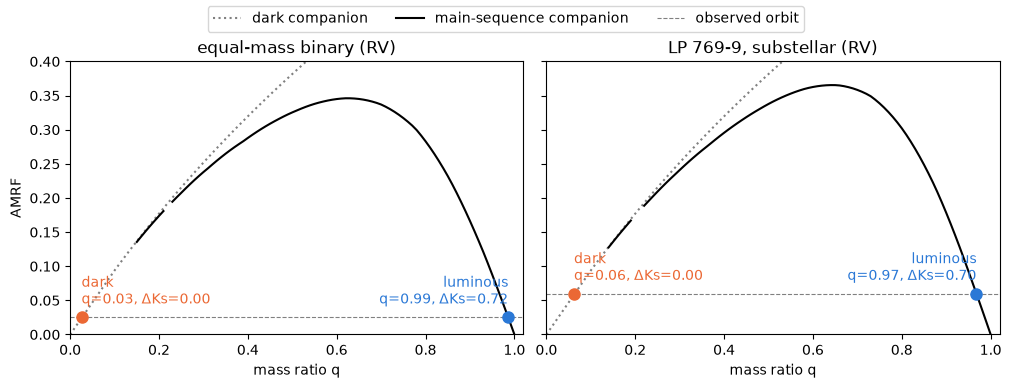

In [2]:
colour = {'dark': SINGLE, 'luminous': BINARY}
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True, layout='constrained')
for ax, (sid, (name, a0, plx, period, m1)) in zip(axes, SYSTEMS.items()):
    a_obs = amrf_observed(a0, plx, period, m1)
    ax.plot([0, *Q_GRID], amrf([0, *Q_GRID], 0), ':', color='grey', label='dark companion')
    ax.plot(Q_GRID, amrf(Q_GRID, locus(m1, model=model)[0]), 'k', label='main-sequence companion')
    ax.axhline(a_obs, color='grey', ls='--', lw=.8, label='observed orbit')
    for r in roots[sid]:
        ax.plot(r['q'], a_obs, 'o', ms=8, color=colour[r['kind']])
        ax.annotate(f"{r['kind']}\nq={r['q']:.2f}, ΔKs={r['delta_Ks']:.2f}", (r['q'], a_obs), xytext=(0, 10),
                    textcoords='offset points', ha='left' if r['q'] < .5 else 'right', color=colour[r['kind']])
    ax.set(title=name, xlabel='mass ratio q', xlim=(0, 1.02), ylim=(0, .4))
axes[0].set_ylabel('AMRF')
fig.legend(*axes[0].get_legend_handles_labels(), loc='outside upper center', ncol=3);

Every orbit has two solutions: a dark companion at $q\approx0.03$–0.06, and a luminous
near-twin at $q\approx0.97$–0.99 whose light almost cancels the photocentre motion.
The orbit alone cannot tell them apart; the twin predicts a pair ~0.7 mag brighter in $K_s$.

## Let the observed SED choose
`rank_roots` fits the same absolute XP + 2MASS fluxes at each solution: a single star at the
dark root, a binary with $q$ fixed at the luminous root. In the plots, *single* is the dark
root and *binary* the luminous root. The two-body parallax sets the scale.

equal-mass binary (RV): dark delta=637, luminous delta=0
LP 769-9, substellar (RV): dark delta=0, luminous delta=1118


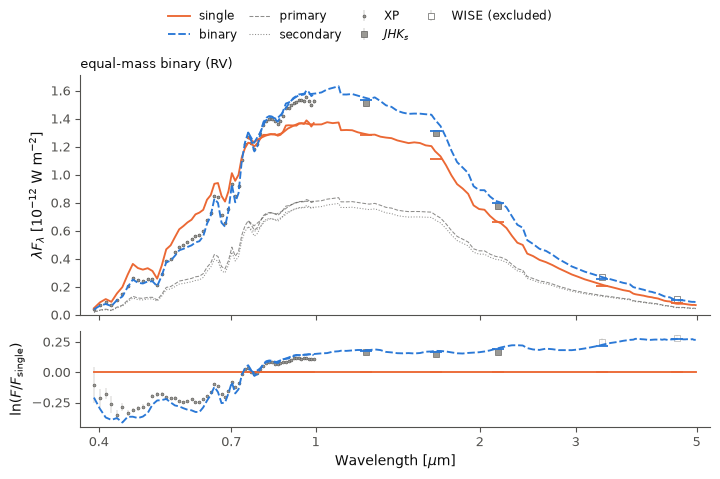

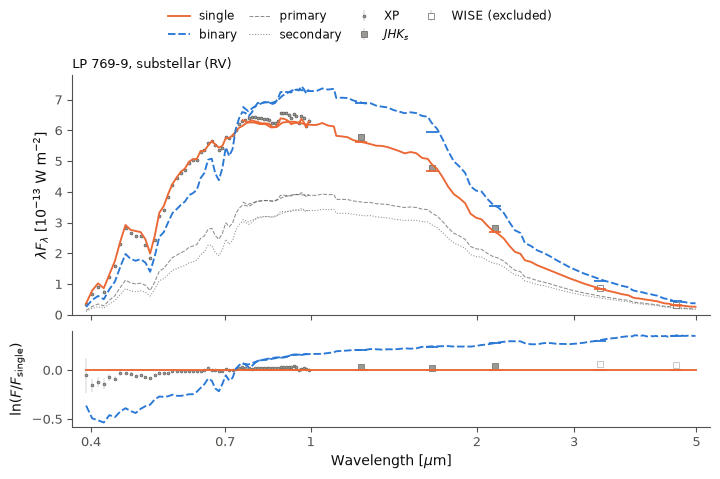

In [3]:
for sid, (name, a0, plx, period, m1) in SYSTEMS.items():
    sed = download(sid, cache_dir='data')
    fits = {r['kind']: r for r in rank_roots(sed, roots[sid], parallax_mas=plx, model=model)}
    print(f"{name}: dark delta={fits['dark']['delta']:.0f}, luminous delta={fits['luminous']['delta']:.0f}")
    plot(sed, {'single': fits['dark']['fit'], 'binary': fits['luminous']['fit']}, title=name)

`delta` is the objective above the best solution (0 = preferred). From XP and 2MASS alone,
the SED picks the luminous root for the binary and the dark root for LP 769-9, as the RVs do.
The CMD agrees: the binary lies 0.68 mag above the single-star sequence in $K_s$
(predicted 0.72 mag); LP 769-9 lies 0.15 mag above it.

## Towards DR4 epoch astrometry
For a luminous companion, the photocentre orbit is the primary orbit scaled by
$(q-\beta)/(q(1+\beta))$. sedkit returns this factor, so an SED and an epoch-astrometry
likelihood can share one $M_1$ and $q$. This is a model calculation; no epoch astrometry is fitted here.

In [4]:
pair = model.evaluate(m1, 0.97, 5.0, 0.0)
print(f"beta_G = {pair['beta_g']:.2f}, a_phot / a_1 = {pair['a_phot_over_a1']:.3f}")

beta_G = 0.81, a_phot / a_1 = 0.091


## Scope
Two systems demonstrate the test; they are not a contamination rate. The companion is a
coeval main-sequence star of the bundled model; white dwarfs and triples are not modelled,
and extinction is zero. Primary mass, age and metallicity are inputs.

**Discussion:** how many DR3/DR4 astrometric brown-dwarf candidates have a luminous solution
that their SED prefers?

Without a spectrum: `python -m sedkit.orbit --a0 0.6978 --parallax 13.913 --period 339.57 --m1 0.686`.
Method: [photocentre orbits](../docs/orbit.md).